In [1]:
using LinearAlgebra
using Plots

function param_method(A, b; tau, tol=1e-5, maxiter=200000)
    n = length(b)
    x = zeros(eltype(b), n)

    for k in 1:maxiter
        r = b - A * x
        x_next = x + tau * r
        if norm(x_next - x) < tol
            return x_next, k
        end
        x = x_next
    end

    return x, maxiter
end

param_method (generic function with 1 method)

In [2]:
function analyze_for_random_system(n=5,num_tau=20)
    B = rand(n, n)
    A = B' * B + n * I
    b = rand(n)
    
    λ = eigvals(A)
    λ_max = maximum(λ)
    λ_min = minimum(λ)
    
    tau_values = range(0.01, 0.9 * 2 / λ_max, length=num_tau)

    iters = Float64[]
    times_ms = Float64[]

    println("τ\t\tитерации\tвремя (мс)")
    println("---------------------------------------")

    for tau in tau_values
        t = @elapsed begin
            _, k = param_method(A, b; tau=tau)
        end

        push!(iters, k)
        push!(times_ms, t * 1000)

        println("$(round(tau, digits=4))\t\t$k\t\t$(round(t*1000, digits=3))")
    end

    tau_opt = 2 / (λ_max + λ_min)

    p_iters = plot(
        tau_values, iters;
        marker=:circle,
        linewidth=2,
        xlabel="τ",
        ylabel="Число итераций",
        title="Сходимость по числу итераций (n = $n)",
        legend=false,
        grid=true,
    )
    vline!(p_iters, [tau_opt], linestyle=:dash, linewidth=2, color=:red)
    annotate!(p_iters, tau_opt, maximum(iters) / 2,
              text("τ* = $(round(tau_opt, digits=4))", :red, 10))

    p_time = plot(
        tau_values, times_ms;
        marker=:circle,
        linewidth=2,
        xlabel="τ",
        ylabel="Время, мс",
        title="Сходимость по времени (n = $n)",
        legend=false,
        grid=true,
    )
    vline!(p_time, [tau_opt], linestyle=:dash, linewidth=2, color=:red)
    annotate!(p_time, tau_opt, maximum(times_ms) / 2,
              text("τ* = $(round(tau_opt, digits=4))", :red, 10))

    display(plot(p_iters, p_time, layout=(2, 1), size=(800, 800)))

    return (
        A = A,
        b = b,
        tau_values = tau_values,
        iterations = iters,
        times_ms = times_ms,
        lambda_min = λ_min,
        lambda_max = λ_max,
        tau_opt = tau_opt,
    )
end

analyze_for_random_system (generic function with 3 methods)

τ		итерации	время (мс)
---------------------------------------
0.01		62		1.237
0.0123		52		0.015
0.0147		44		0.014
0.017		39		0.014
0.0194		34		0.014
0.0217		31		0.01
0.024		28		0.008
0.0264		25		0.007
0.0287		23		0.006
0.0311		22		0.006
0.0334		20		0.005
0.0357		19		0.005
0.0381		17		0.005
0.0404		16		0.005
0.0428		15		0.003
0.0451		15		0.005
0.0474		16		0.004
0.0498		21		0.006
0.0521		27		0.006
0.0545		39		0.01


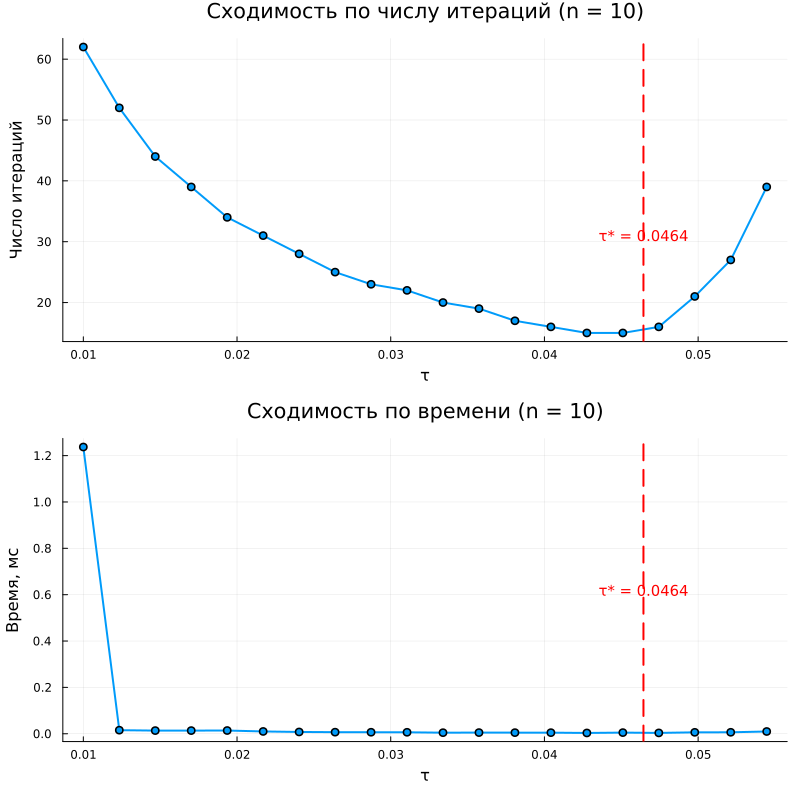

(A = [13.178286088010946 2.0629044638786977 … 2.582836225882942 1.4948360263836957; 2.0629044638786977 12.867733505012284 … 2.410431735866813 1.2054726939382316; … ; 2.582836225882942 2.410431735866813 … 13.387192451726529 1.4601650437706275; 1.4948360263836957 1.2054726939382316 … 1.4601650437706275 11.517908099452455], b = [0.3514811231296896, 0.348657773130996, 0.03469938288646357, 0.5451365822332622, 0.451908269413404, 0.06695981364003567, 0.029957475894518804, 0.12138632755495227, 0.20763888894770954, 0.7087012122207839], tau_values = 0.01:0.002340109883623087:0.05446208778883865, iterations = [62.0, 52.0, 44.0, 39.0, 34.0, 31.0, 28.0, 25.0, 23.0, 22.0, 20.0, 19.0, 17.0, 16.0, 15.0, 15.0, 16.0, 21.0, 27.0, 39.0], times_ms = [1.2371999999999999, 0.015400000000000002, 0.013600000000000001, 0.013600000000000001, 0.013900000000000001, 0.0099, 0.007700000000000001, 0.0068000000000000005, 0.0065, 0.0063, 0.0046, 0.005, 0.0048, 0.0047, 0.0034000000000000002, 0.0049, 0.0036, 0.0061, 0.006

In [3]:
results_10 = analyze_for_random_system(10)

In [4]:
A = [
    4.0 1.0 1.0
    1.0 3.0 0.0
    1.0 0.0 2.0
]
b = [1.0, 2.0, 3.0]

# === вычисление lambda_min, lambda_max ===
λ = eigvals(A)
λ_min = minimum(λ)
λ_max = maximum(λ)
tau_opt = 2 / (λ_min + λ_max)

println("λ = ", λ)
println("tau_opt = ", tau_opt)

x_iter, iters = param_method(A, b; tau=tau_opt)

println("=== ITERATIVE METHOD ===")
println("Solution: ", x_iter)
println("Iterations: ", iters)

λ = [1.4679111137620438, 2.652703644666139, 4.879385241571816]
tau_opt = 0.3150947880855332
=== ITERATIVE METHOD ===
Solution: [-0.3684195831607548, 0.7894705510316996, 1.6842036787367807]
Iterations: 20
